# Multiple Linear Regression Assignment — Toyota Corolla Price Prediction

## Objective
The objective of this assignment is to perform Multiple Linear Regression analysis to predict the **Price** of Toyota Corolla cars based on multiple attributes.

This notebook includes:

1. Data loading  
2. Exploratory Data Analysis (EDA)  
3. Missing value and duplicate handling  
4. Data preprocessing  
5. Train-test split  
6. Minimum 3 different Multiple Linear Regression models  
7. Model coefficient interpretation  
8. Model evaluation using MAE, MSE, RMSE, and R² Score  
9. Ridge Regression  
10. Lasso Regression  
11. Multicollinearity check using VIF  
12. Interview questions and answers  
13. Final conclusion

In [4]:
!pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

## 1. Import Required Libraries

In [5]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# For VIF / multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

In [6]:
df = pd.read_csv("ToyotaCorolla - MLR.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (1436, 11)


,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


## 3. Dataset Information

The target variable is:

- `Price`

Independent variables include:

- `Age_08_04`
- `KM`
- `Fuel_Type`
- `HP`
- `Automatic`
- `cc`
- `Doors`
- `Cylinders`
- `Gears`
- `Weight`

In [7]:
print("Dataset Information:")
df.info()

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB

Column Names:
['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight']


## 4. Missing Values and Duplicate Check

In [8]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicate rows if present
df = df.drop_duplicates()

print("\nShape after removing duplicates:", df.shape)

Missing Values:
Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

Duplicate Rows: 1

Shape after removing duplicates: (1435, 11)


## 5. Summary Statistics

In [9]:
display(df.describe())

print("Categorical Summary:")
display(df.describe(include="object"))

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.0,1435.000000,1435.000000
mean,10720.915679,55.980488,68571.782578,101.491986,0.055749,1576.560976,4.032753,4.0,5.026481,1072.287108
std,3608.732978,18.563312,37491.094553,14.981408,0.229517,424.387533,0.952667,0.0,0.188575,52.251882
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.000000,2.000000,4.0,3.000000,1000.000000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.000000,3.000000,4.0,5.000000,1040.000000
50%,9900.000000,61.000000,63451.000000,110.000000,0.000000,1600.000000,4.000000,4.0,5.000000,1070.000000
75%,11950.000000,70.000000,87041.500000,110.000000,0.000000,1600.000000,5.000000,4.0,5.000000,1085.000000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.000000,5.000000,4.0,6.000000,1615.000000


Categorical Summary:


,Fuel_Type
count,1435
unique,3
top,Petrol
freq,1264


## 6. Exploratory Data Analysis

### 6.1 Price Distribution

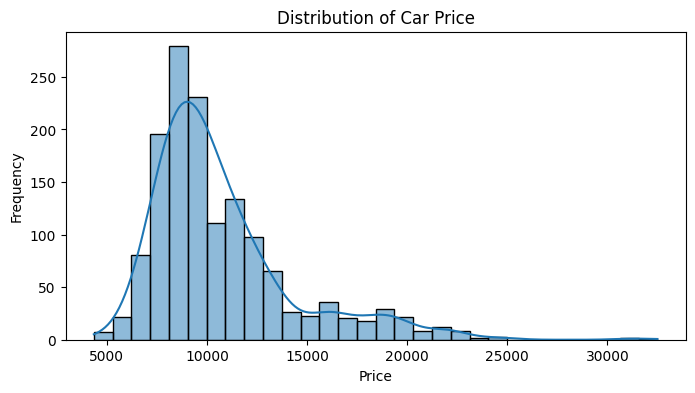

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(df["Price"], kde=True, bins=30)
plt.title("Distribution of Car Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

### 6.2 Numerical Feature Distributions

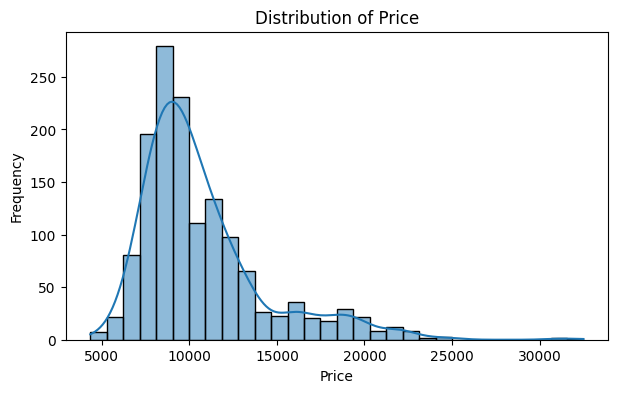

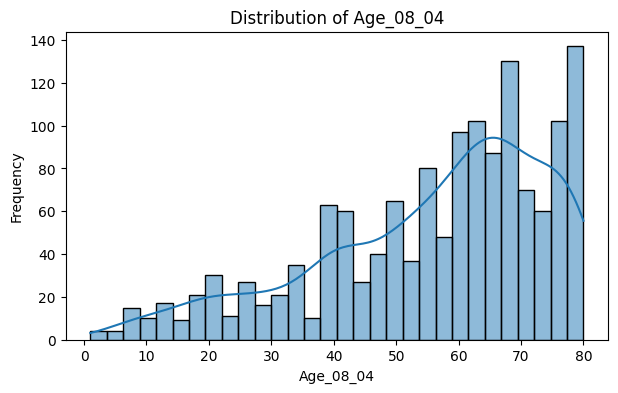

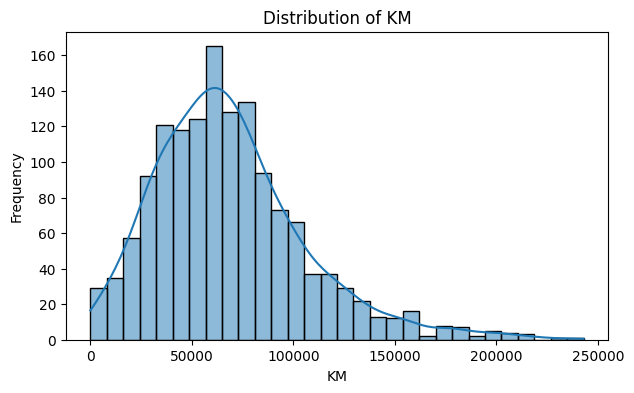

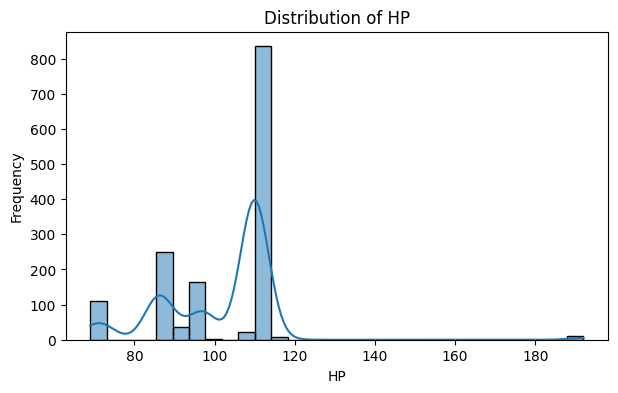

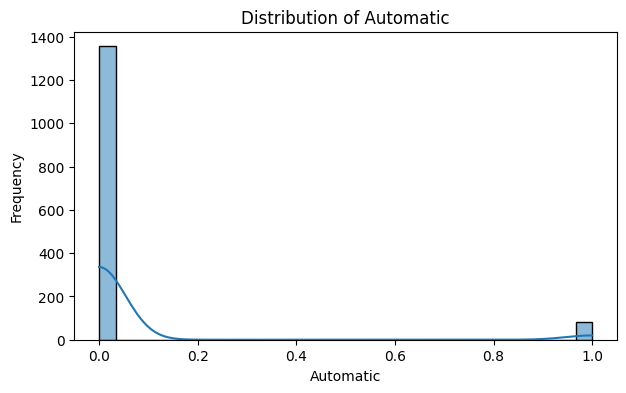

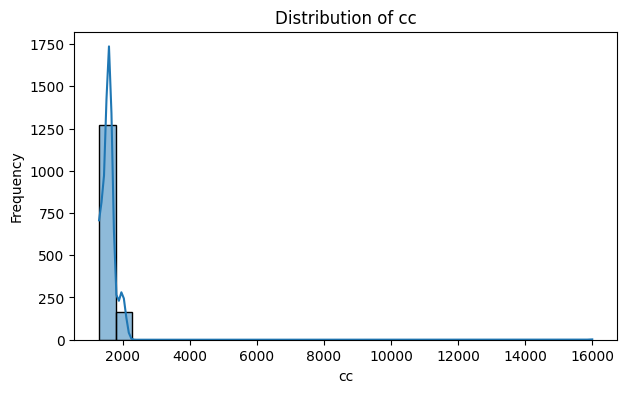

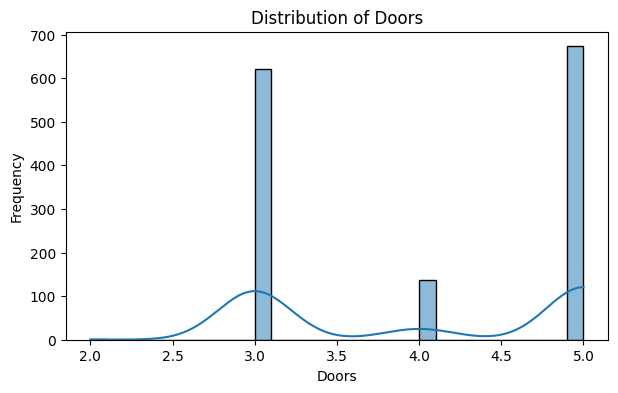

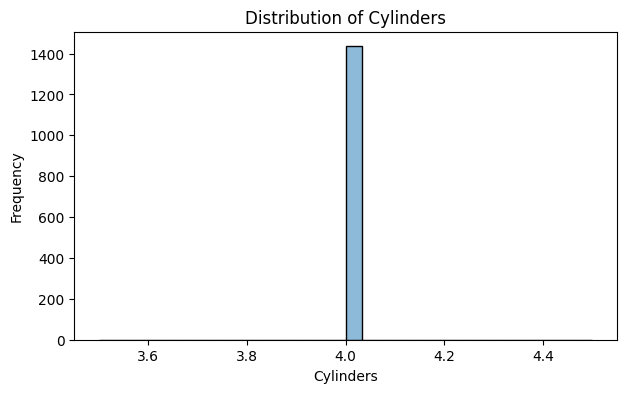

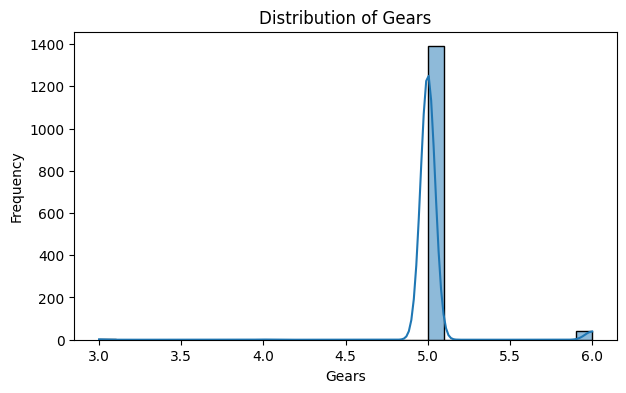

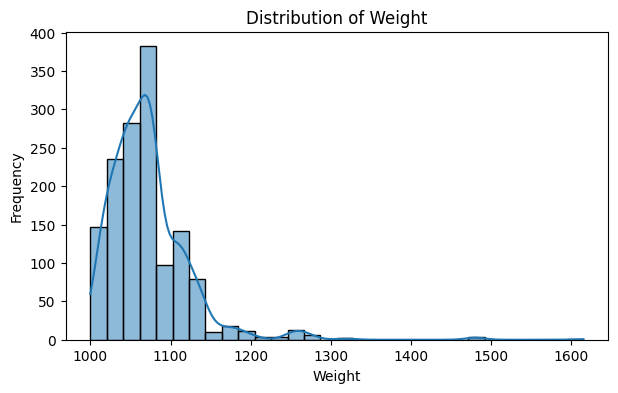

In [11]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

for col in numerical_columns:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### 6.3 Boxplots for Outlier Detection

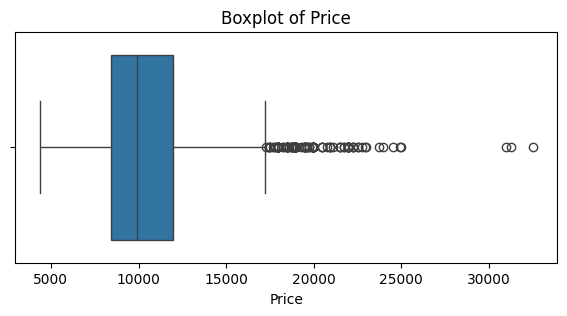

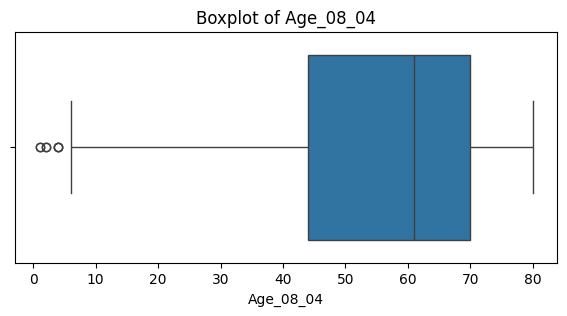

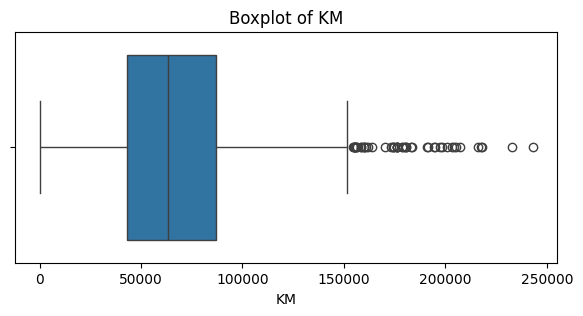

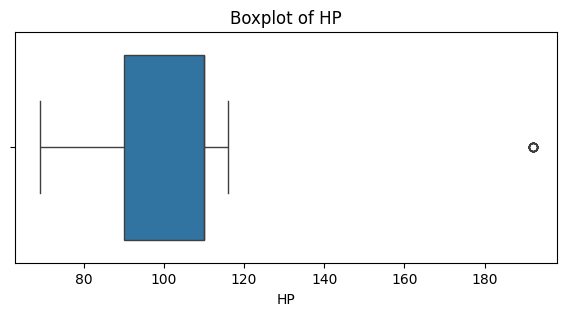

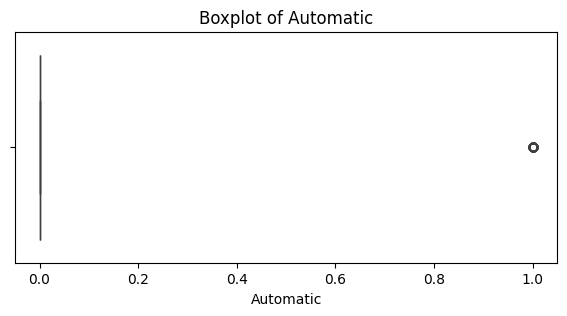

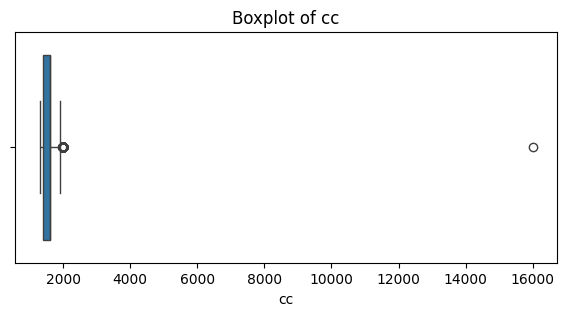

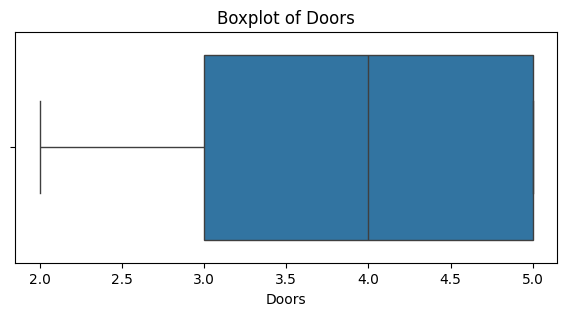

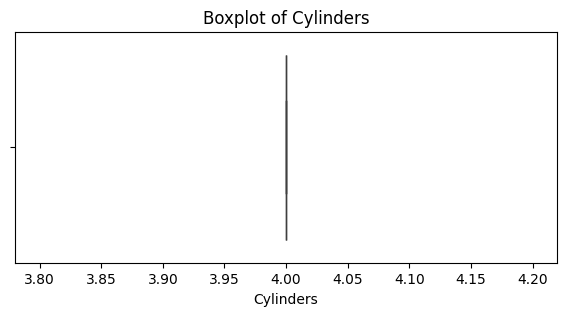

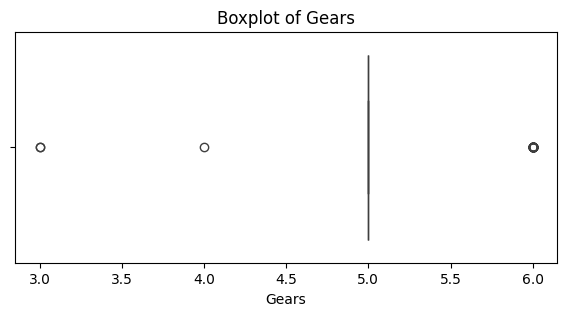

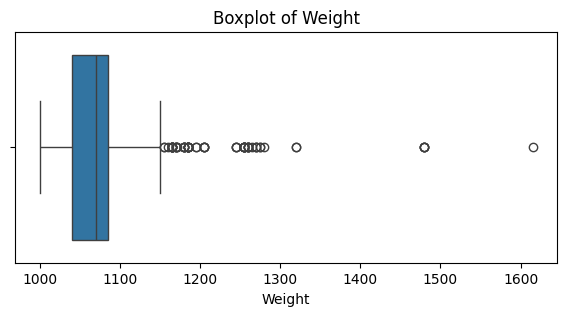

In [12]:
for col in numerical_columns:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### 6.4 Fuel Type Count

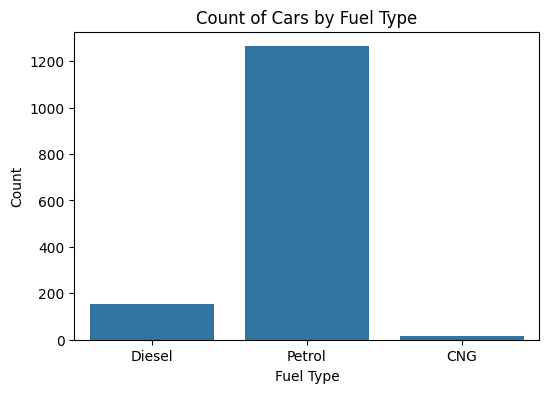

Fuel_Type
Petrol    1264
Diesel     154
CNG         17
Name: count, dtype: int64


In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Fuel_Type")
plt.title("Count of Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.show()

print(df["Fuel_Type"].value_counts())

### 6.5 Relationship Between Age and Price

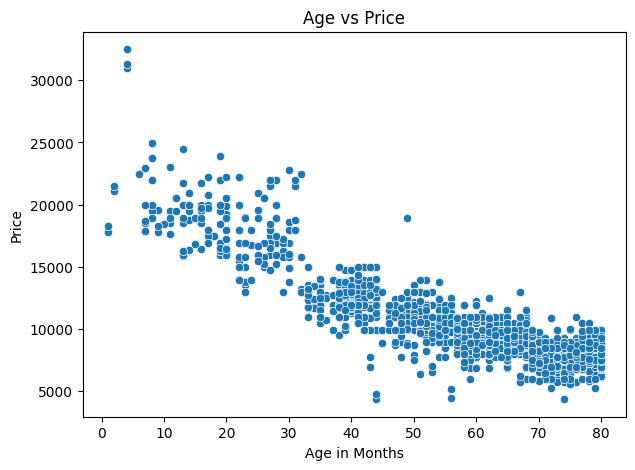

In [14]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="Age_08_04", y="Price")
plt.title("Age vs Price")
plt.xlabel("Age in Months")
plt.ylabel("Price")
plt.show()

### 6.6 Relationship Between KM and Price

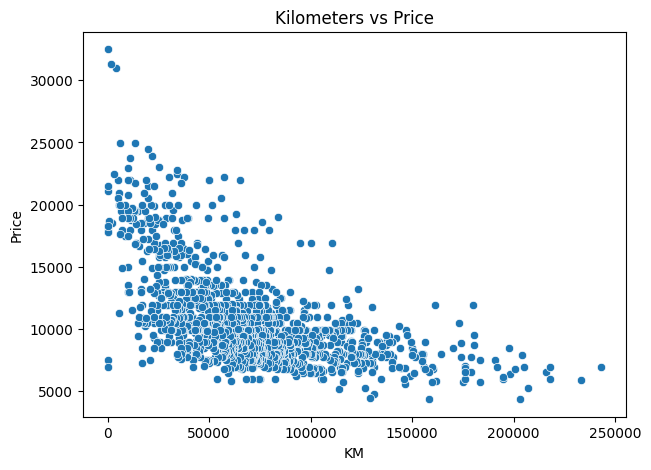

In [15]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="KM", y="Price")
plt.title("Kilometers vs Price")
plt.xlabel("KM")
plt.ylabel("Price")
plt.show()

### 6.7 Correlation Heatmap

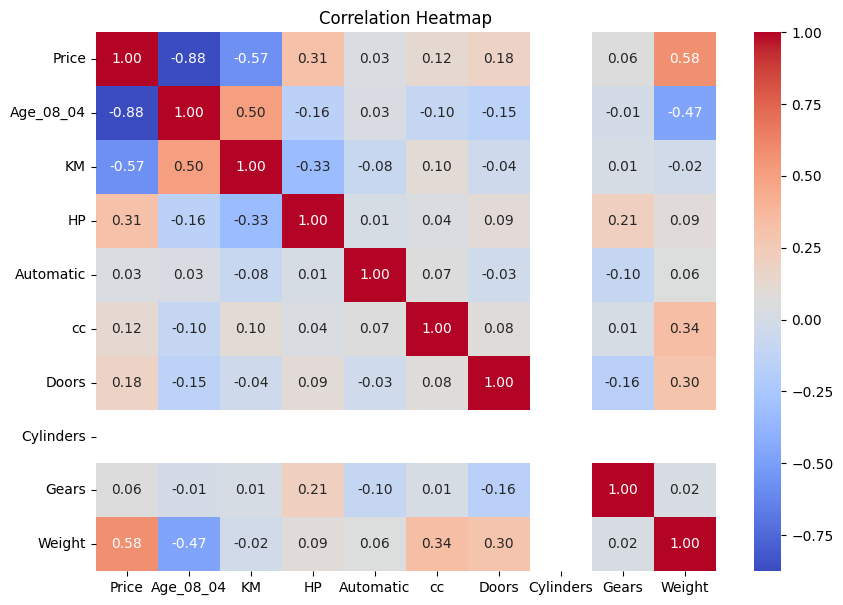

In [16]:
plt.figure(figsize=(10,7))
corr_matrix = df.select_dtypes(include=["int64", "float64"]).corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 7. Outlier Treatment using IQR Capping

Extreme values can affect Linear Regression because the model tries to minimize squared errors.

Here, we cap outliers using the IQR method for numerical columns.

In [17]:
df_capped = df.copy()

for col in numerical_columns:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_capped[col] = np.where(df_capped[col] < lower_limit, lower_limit, df_capped[col])
    df_capped[col] = np.where(df_capped[col] > upper_limit, upper_limit, df_capped[col])

print("Outlier capping completed.")
display(df_capped.head())

Outlier capping completed.


,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500.0,23.0,46986.0,Diesel,90.0,0.0,1900.0,3.0,4.0,5.0,1152.5
1,13750.0,23.0,72937.0,Diesel,90.0,0.0,1900.0,3.0,4.0,5.0,1152.5
2,13950.0,24.0,41711.0,Diesel,90.0,0.0,1900.0,3.0,4.0,5.0,1152.5
3,14950.0,26.0,48000.0,Diesel,90.0,0.0,1900.0,3.0,4.0,5.0,1152.5
4,13750.0,30.0,38500.0,Diesel,90.0,0.0,1900.0,3.0,4.0,5.0,1152.5


## 8. Define Features and Target

In [18]:
target = "Price"

X = df_capped.drop(columns=[target])
y = df_capped[target]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

display(X.head())

Feature Shape: (1435, 10)
Target Shape: (1435,)


,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,23.0,46986.0,Diesel,90.0,0.0,1900.0,3.0,4.0,5.0,1152.5
1,23.0,72937.0,Diesel,90.0,0.0,1900.0,3.0,4.0,5.0,1152.5
2,24.0,41711.0,Diesel,90.0,0.0,1900.0,3.0,4.0,5.0,1152.5
3,26.0,48000.0,Diesel,90.0,0.0,1900.0,3.0,4.0,5.0,1152.5
4,30.0,38500.0,Diesel,90.0,0.0,1900.0,3.0,4.0,5.0,1152.5


## 9. Train-Test Split

The dataset is split into:

- 80% training data
- 20% testing data

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1148, 10)
X_test shape: (287, 10)
y_train shape: (1148,)
y_test shape: (287,)


## 10. Preprocessing Setup

### Numerical columns
- Scaled using StandardScaler

### Categorical columns
- Converted using One-Hot Encoding

In [20]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:", numeric_features)
print("Categorical Features:", categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessor created successfully.")

Numerical Features: ['Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight']
Categorical Features: ['Fuel_Type']
Preprocessor created successfully.


# Model 1: Multiple Linear Regression with All Features

In [21]:
model_1 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model_1.fit(X_train, y_train)

y_pred_1 = model_1.predict(X_test)

print("Model 1 trained successfully.")

Model 1 trained successfully.


## Model 1 Evaluation

In [22]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"Evaluation Metrics for {model_name}")
    print("-" * 40)
    print("MAE :", round(mae, 2))
    print("MSE :", round(mse, 2))
    print("RMSE:", round(rmse, 2))
    print("R² Score:", round(r2, 4))

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }

results = []

results.append(evaluate_model(y_test, y_pred_1, "Model 1 - All Features"))

Evaluation Metrics for Model 1 - All Features
----------------------------------------
MAE : 874.11
MSE : 1275108.72
RMSE: 1129.21
R² Score: 0.8505


# Model 2: Multiple Linear Regression with Selected Important Features

Selected features are based on business understanding and correlation:

- `Age_08_04`
- `KM`
- `HP`
- `Weight`
- `Fuel_Type`

In [23]:
selected_features_model_2 = ["Age_08_04", "KM", "HP", "Weight", "Fuel_Type"]

X2 = df_capped[selected_features_model_2]
y2 = df_capped["Price"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42
)

numeric_features_2 = X2.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_2 = X2.select_dtypes(include=["object"]).columns.tolist()

preprocessor_2 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_2),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features_2)
    ]
)

model_2 = Pipeline(steps=[
    ("preprocessor", preprocessor_2),
    ("regressor", LinearRegression())
])

model_2.fit(X2_train, y2_train)

y_pred_2 = model_2.predict(X2_test)

results.append(evaluate_model(y2_test, y_pred_2, "Model 2 - Selected Features"))

Evaluation Metrics for Model 2 - Selected Features
----------------------------------------
MAE : 865.56
MSE : 1264729.38
RMSE: 1124.6
R² Score: 0.8517


# Model 3: Multiple Linear Regression without Highly Constant / Less Useful Columns

`Cylinders` usually has the same value for almost all cars, so it may not provide useful predictive power.

In this model, we remove `Cylinders`.

In [24]:
X3 = df_capped.drop(columns=["Price", "Cylinders"])
y3 = df_capped["Price"]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y3,
    test_size=0.20,
    random_state=42
)

numeric_features_3 = X3.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_3 = X3.select_dtypes(include=["object"]).columns.tolist()

preprocessor_3 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_3),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features_3)
    ]
)

model_3 = Pipeline(steps=[
    ("preprocessor", preprocessor_3),
    ("regressor", LinearRegression())
])

model_3.fit(X3_train, y3_train)

y_pred_3 = model_3.predict(X3_test)

results.append(evaluate_model(y3_test, y_pred_3, "Model 3 - Without Cylinders"))

Evaluation Metrics for Model 3 - Without Cylinders
----------------------------------------
MAE : 874.11
MSE : 1275108.72
RMSE: 1129.21
R² Score: 0.8505


## 11. Compare All 3 Linear Regression Models

,Model,MAE,MSE,RMSE,R2 Score
0,Model 1 - All Features,874.113042,1.275109e+06,1129.207119,0.850484
1,Model 2 - Selected Features,865.564027,1.264729e+06,1124.601875,0.851701
2,Model 3 - Without Cylinders,874.113042,1.275109e+06,1129.207119,0.850484


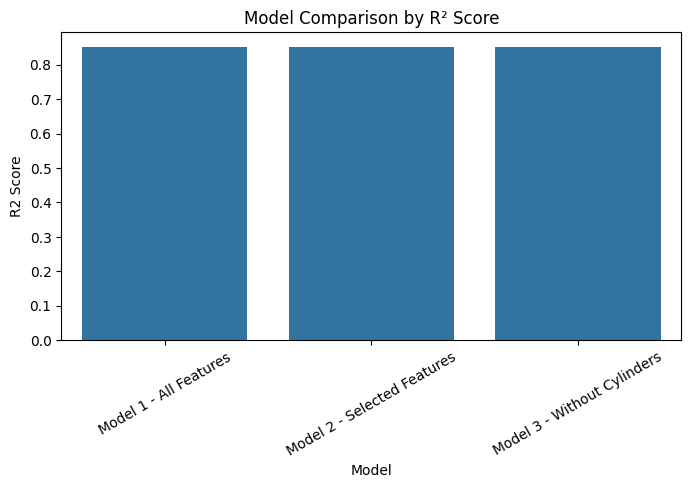

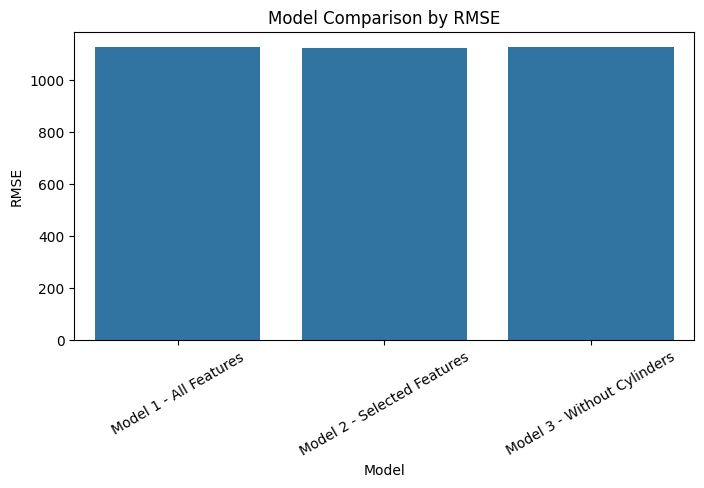

In [25]:
results_df = pd.DataFrame(results)
display(results_df)

plt.figure(figsize=(8,4))
sns.barplot(data=results_df, x="Model", y="R2 Score")
plt.title("Model Comparison by R² Score")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8,4))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("Model Comparison by RMSE")
plt.xticks(rotation=30)
plt.show()

## 12. Interpret Coefficients of Model 1

For Linear Regression:

- Positive coefficient means as the feature increases, price increases.
- Negative coefficient means as the feature increases, price decreases.

,Feature,Coefficient
10,Fuel_Type_Petrol,1.009305e+03
8,Weight,9.765952e+02
9,Fuel_Type_Diesel,9.460781e+02
2,HP,3.946400e+02
3,Automatic,2.842171e-13
7,Gears,-2.273737e-13
6,Cylinders,-4.831691e-13
5,Doors,-1.221588e+02
4,cc,-4.627095e+02
1,KM,-5.158060e+02


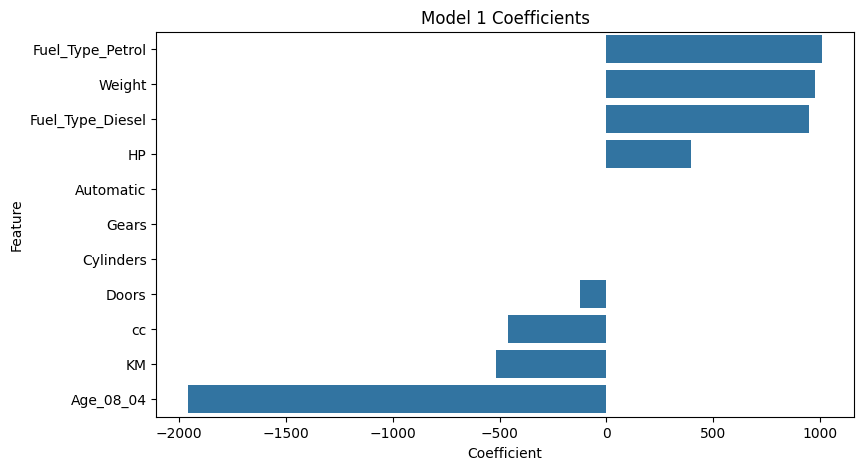

In [26]:
# Fit preprocessor separately to obtain transformed feature names
model_1.fit(X_train, y_train)

fitted_preprocessor = model_1.named_steps["preprocessor"]
linear_regressor = model_1.named_steps["regressor"]

encoded_cat_features = fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_features)

coefficients_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": linear_regressor.coef_
}).sort_values(by="Coefficient", ascending=False)

display(coefficients_df)

plt.figure(figsize=(9,5))
sns.barplot(data=coefficients_df, x="Coefficient", y="Feature")
plt.title("Model 1 Coefficients")
plt.show()

## 13. Actual vs Predicted Price

,Actual Price,Predicted Price
753,9950.0,10188.039379
858,7995.0,10105.027184
630,7500.0,9095.655565
1412,9950.0,9312.985921
975,8950.0,8872.240365
800,8995.0,8902.905632
1030,9450.0,8292.703209
1372,6750.0,8363.410288
260,11950.0,11634.305318
317,10950.0,12163.301453


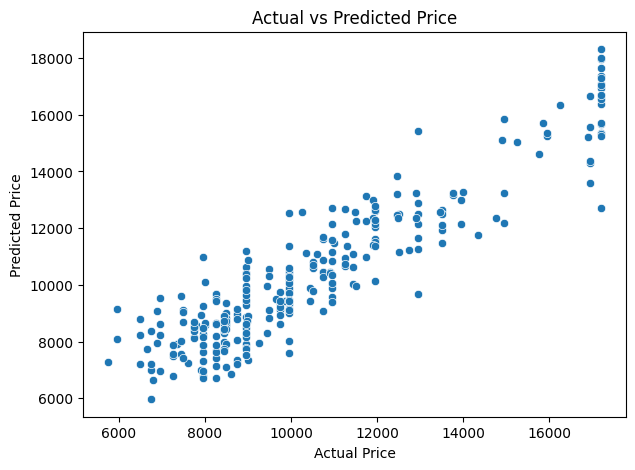

In [27]:
comparison_df = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred_1
})

display(comparison_df.head(10))

plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=y_pred_1)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

## 14. Residual Analysis

Residual = Actual value - Predicted value

Ideally, residuals should be randomly distributed around zero.

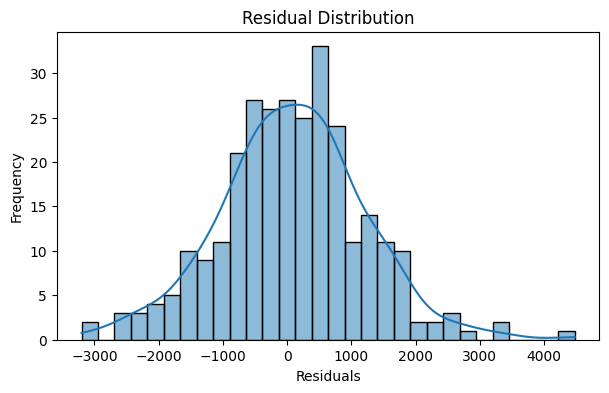

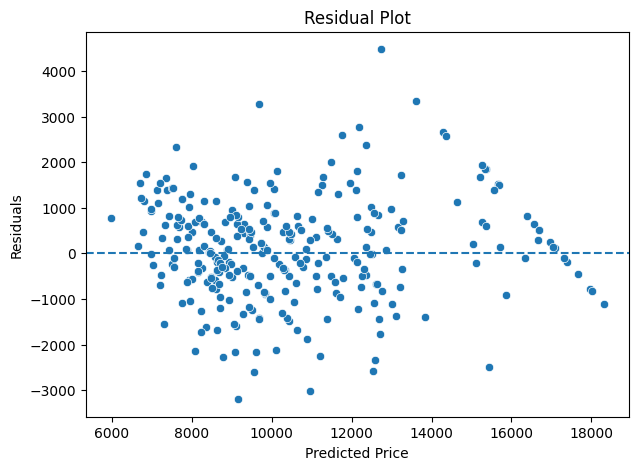

In [28]:
residuals = y_test - y_pred_1

plt.figure(figsize=(7,4))
sns.histplot(residuals, kde=True, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7,5))
sns.scatterplot(x=y_pred_1, y=residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

## 15. Ridge Regression

Ridge Regression is a regularized version of Linear Regression.

It helps reduce overfitting and handles multicollinearity by adding L2 penalty.

In [29]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

results.append(evaluate_model(y_test, ridge_pred, "Ridge Regression"))

Evaluation Metrics for Ridge Regression
----------------------------------------
MAE : 875.56
MSE : 1278804.57
RMSE: 1130.84
R² Score: 0.8501


## 16. Lasso Regression

Lasso Regression adds L1 penalty.

It can reduce some coefficients to zero, so it is also useful for feature selection.

In [30]:
lasso_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Lasso(alpha=0.1, max_iter=10000))
])

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

results.append(evaluate_model(y_test, lasso_pred, "Lasso Regression"))

Evaluation Metrics for Lasso Regression
----------------------------------------
MAE : 874.28
MSE : 1275511.58
RMSE: 1129.39
R² Score: 0.8504


## 17. Final Model Comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Model 1 - All Features,874.113042,1.275109e+06,1129.207119,0.850484
1,Model 2 - Selected Features,865.564027,1.264729e+06,1124.601875,0.851701
2,Model 3 - Without Cylinders,874.113042,1.275109e+06,1129.207119,0.850484
3,Ridge Regression,875.558387,1.278805e+06,1130.842415,0.850051
4,Lasso Regression,874.276584,1.275512e+06,1129.385487,0.850437


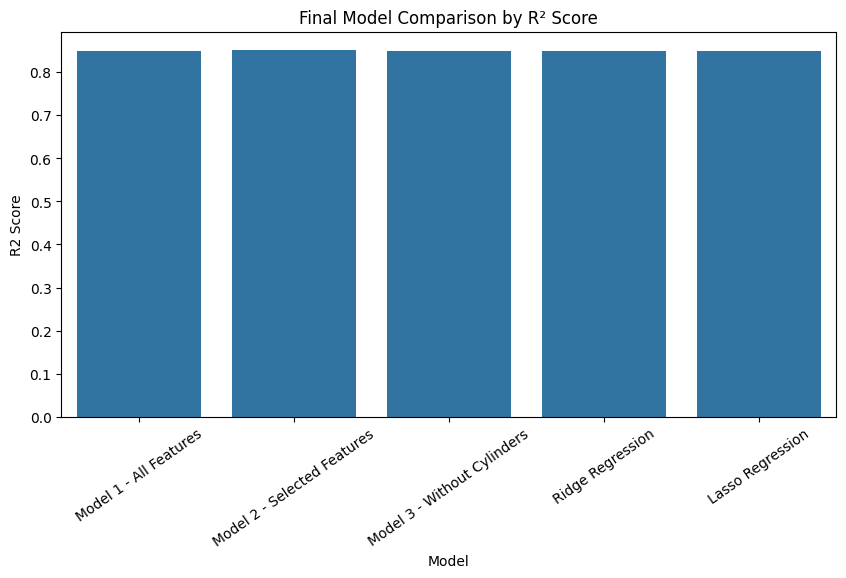

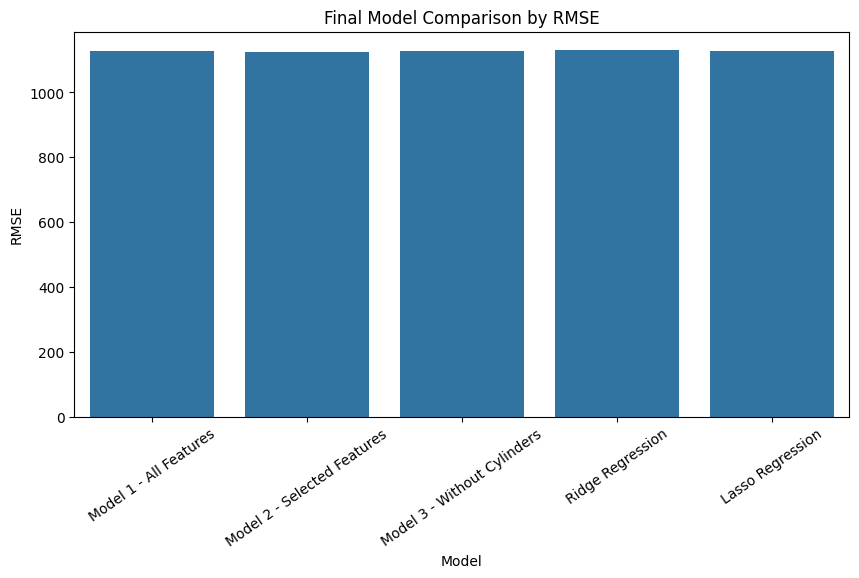

In [31]:
final_results_df = pd.DataFrame(results)
display(final_results_df)

plt.figure(figsize=(10,5))
sns.barplot(data=final_results_df, x="Model", y="R2 Score")
plt.title("Final Model Comparison by R² Score")
plt.xticks(rotation=35)
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=final_results_df, x="Model", y="RMSE")
plt.title("Final Model Comparison by RMSE")
plt.xticks(rotation=35)
plt.show()

## 18. Multicollinearity Check using VIF

VIF stands for Variance Inflation Factor.

- VIF = 1 means no multicollinearity.
- VIF between 1 and 5 is usually acceptable.
- VIF above 5 or 10 indicates multicollinearity.

In [32]:
# Use only numerical columns for VIF
vif_data = df_capped.select_dtypes(include=["int64", "float64"]).drop(columns=["Price"])

# Remove columns with zero variance because VIF cannot be calculated properly for constant columns
vif_data = vif_data.loc[:, vif_data.nunique() > 1]

# Add constant
vif_data_const = sm.add_constant(vif_data)

vif_df = pd.DataFrame()
vif_df["Feature"] = vif_data_const.columns
vif_df["VIF"] = [variance_inflation_factor(vif_data_const.values, i) for i in range(vif_data_const.shape[1])]

display(vif_df)

,Feature,VIF
0,const,2183.082246
1,Age_08_04,2.114829
2,KM,1.920202
3,HP,1.253571
4,cc,2.824547
5,Doors,1.283791
6,Weight,3.704059


## 19. Important Insights

1. `Age_08_04` usually has a strong negative relationship with price. As the car becomes older, price decreases.
2. `KM` also has a negative relationship with price. More kilometers usually reduce resale value.
3. `Weight` can have a positive impact because heavier cars may represent bigger or better-equipped models.
4. `HP` can also increase price because more powerful cars may be valued higher.
5. Fuel type can affect price because Diesel, Petrol, and CNG cars can have different market values.
6. Ridge and Lasso help improve model stability when features are correlated.

## 20. Interview Questions

### Q1. What is Normalization and Standardization and how is it helpful?

**Normalization** is a scaling technique that converts values into a fixed range, usually between 0 and 1.

Formula:

`X_normalized = (X - X_min) / (X_max - X_min)`

It is useful when we want all features to have the same scale.

**Standardization** converts values into a distribution with mean 0 and standard deviation 1.

Formula:

`Z = (X - mean) / standard deviation`

It is useful when features have different units or scales.

### Why are they helpful?

They are helpful because:

1. They bring all features to a comparable scale.
2. They improve model training for algorithms sensitive to scale.
3. They prevent large-valued features from dominating smaller-valued features.
4. They are especially important for Ridge and Lasso Regression.

---

### Q2. What techniques can be used to address multicollinearity in Multiple Linear Regression?

Multicollinearity occurs when independent variables are highly correlated with each other.

Techniques to handle multicollinearity:

1. **Remove highly correlated features**  
   If two variables provide similar information, remove one.

2. **Use VIF**  
   Variance Inflation Factor helps detect multicollinearity.

3. **Apply Ridge Regression**  
   Ridge reduces the effect of multicollinearity using L2 regularization.

4. **Apply Lasso Regression**  
   Lasso can shrink some feature coefficients to zero.

5. **Combine related variables**  
   Create a new meaningful feature from correlated variables.

6. **Use PCA**  
   Principal Component Analysis transforms correlated features into independent components.

## 21. Final Conclusion

In this assignment, Multiple Linear Regression was used to predict Toyota Corolla car prices. The dataset was analyzed using EDA, summary statistics, histograms, boxplots, scatter plots, and correlation heatmap.

The data was preprocessed by removing duplicates, treating outliers, encoding categorical variables, and scaling numerical variables. Three different Multiple Linear Regression models were built and compared. Ridge and Lasso Regression were also applied to improve model stability and handle multicollinearity.

The model performance was evaluated using MAE, MSE, RMSE, and R² Score. The analysis showed that features like age, kilometers driven, weight, horsepower, and fuel type are important in predicting car price.